In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [5]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_prob = model.predict_proba(X_train)
    val_prob = model.predict_proba(X_val)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_loss = log_loss(y_train, train_prob)
    val_loss = log_loss(y_val, val_prob)

    weights = model.coef_

    return {
        "train_acc": train_acc,
        "val_acc": val_acc,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "weights": weights
    }

In [6]:
baseline_model = LogisticRegression(penalty=None, max_iter=5000)

baseline_results = evaluate_model(
    baseline_model, X_train, y_train, X_val, y_val
)

baseline_results

{'train_acc': 1.0,
 'val_acc': 0.9385964912280702,
 'train_loss': 0.00017713665366675505,
 'val_loss': 1.9962744443928955,
 'weights': array([[   9.43309636,  -16.98638813,   40.02092582,   10.89014962,
            5.03344322,  274.94009818, -134.8381584 , -266.18473606,
           40.99650503, -168.01794604, -259.63946217,   35.91792789,
          115.35011389, -167.38940131,  -79.54006031,  -97.5741303 ,
          246.60809325,  -70.05165414,   95.95418597,  131.93923412,
         -105.87135969,  -91.92127648,   73.01874488, -103.73668988,
           93.97496151,   29.28537604, -244.05971135,   -8.90816016,
         -169.6548548 ,   59.68383553]])}

In [7]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=5000)

l1_results = evaluate_model(
    l1_model, X_train, y_train, X_val, y_val
)

l1_zero_weights = np.sum(l1_results["weights"] == 0)

l1_results, l1_zero_weights

({'train_acc': 0.989010989010989,
  'val_acc': 0.9736842105263158,
  'train_loss': 0.05304630091830883,
  'val_loss': 0.06836562180207,
  'weights': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
           0.        ,  0.        , -2.40078311,  0.01615723,  0.        ,
          -2.49349418,  0.37921532,  0.        ,  0.        , -0.42849782,
           0.92298619,  0.        ,  0.        ,  0.42936734,  0.25844893,
          -1.18277165, -1.85301948,  0.        , -2.70665086, -0.18931193,
           0.        , -1.31920891,  0.        , -1.01631951,  0.        ]])},
 np.int64(16))

In [9]:
l2_model = LogisticRegression(penalty='l2', max_iter=5000)

l2_results = evaluate_model(
    l2_model, X_train, y_train, X_val, y_val
)

l2_results

{'train_acc': 0.9868131868131869,
 'val_acc': 0.9736842105263158,
 'train_loss': 0.05433742571095533,
 'val_loss': 0.06012955060644868,
 'weights': array([[-0.43190368, -0.38732553, -0.39343248, -0.46521006, -0.07166728,
          0.54016395, -0.8014581 , -1.11980408,  0.23611852,  0.07592093,
         -1.26817815,  0.18887738, -0.61058302, -0.9071857 , -0.31330675,
          0.68249145,  0.17527452, -0.3112999 ,  0.50042502,  0.61622993,
         -0.87984024, -1.35060559, -0.58945273, -0.84184594, -0.54416967,
          0.01611019, -0.94305313, -0.77821726, -1.20820031, -0.15741387]])}

In [8]:
elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=5000
)

elastic_results = evaluate_model(
    elastic_model, X_train, y_train, X_val, y_val
)

elastic_zero_weights = np.sum(elastic_results["weights"] == 0)

elastic_results, elastic_zero_weights

({'train_acc': 0.9868131868131869,
  'val_acc': 0.9736842105263158,
  'train_loss': 0.05493921716547601,
  'val_loss': 0.062392944645575606,
  'weights': array([[-0.33739927, -0.27002882, -0.25595342, -0.35547445,  0.        ,
           0.32015748, -0.60273287, -1.32771424,  0.16662734,  0.        ,
          -1.52206684,  0.19616214, -0.39307292, -0.87986648, -0.33923486,
           0.7157891 ,  0.        , -0.05006252,  0.50300733,  0.4686762 ,
          -1.03019072, -1.45300325, -0.54621461, -0.91793315, -0.45427247,
           0.        , -0.86607904, -0.80111296, -1.15053027,  0.        ]])},
 np.int64(5))

In [10]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "L1", "L2", "ElasticNet"],
    "Train Accuracy": [
        baseline_results["train_acc"],
        l1_results["train_acc"],
        l2_results["train_acc"],
        elastic_results["train_acc"]
    ],
    "Validation Accuracy": [
        baseline_results["val_acc"],
        l1_results["val_acc"],
        l2_results["val_acc"],
        elastic_results["val_acc"]
    ],
    "Train Loss": [
        baseline_results["train_loss"],
        l1_results["train_loss"],
        l2_results["train_loss"],
        elastic_results["train_loss"]
    ],
    "Validation Loss": [
        baseline_results["val_loss"],
        l1_results["val_loss"],
        l2_results["val_loss"],
        elastic_results["val_loss"]
    ]
})

comparison

,Model,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
0,Baseline,1.000000,0.938596,0.000177,1.996274
1,L1,0.989011,0.973684,0.053046,0.068366
2,L2,0.986813,0.973684,0.054337,0.060130
3,ElasticNet,0.986813,0.973684,0.054939,0.062393


In [11]:
print("L1 Zero Weights:", l1_zero_weights)
print("Elastic Net Zero Weights:", elastic_zero_weights)

print("L2 Weight Magnitudes (mean abs):", np.mean(np.abs(l2_results["weights"])))

L1 Zero Weights: 16
Elastic Net Zero Weights: 5
L2 Weight Magnitudes (mean abs): 0.580192178307878


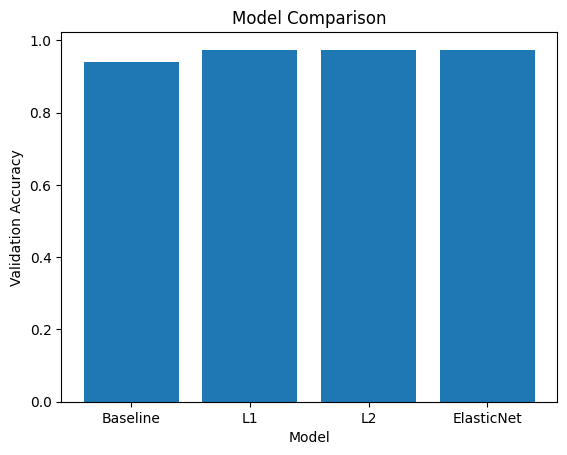

In [12]:
plt.figure()
plt.bar(comparison["Model"], comparison["Validation Accuracy"])
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()